In [2]:
# Celda 1: Extracción
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\10138083\Documents\TFM_UNIR\datos_turbina\gas_turbine_fault_detection.csv')

# Simulamos el dataframe basándonos en tu imagen para que el código sea ejecutable ahora mismo
np.random.seed(42)
columnas = ['Temperature (°C)', 'RPM', 'Torque (Nm)', 'Vibrations (mm/s)', 
            'Power Output (MW)', 'Fuel Flow Rate (kg/s)', 'Air Pressure (kPa)', 
            'Exhaust Gas Temp (°C)', 'Oil Temp (°C)']
X_sim = np.random.rand(1386, 9) * 100 
df = pd.DataFrame(X_sim, columns=columnas)
df['Fault'] = np.random.choice([0, 1], size=1386, p=[0.8, 0.2])

print("Visualización de las primeras 5 filas (Tabla):")
display(df.head()) # En VS Code Notebook, 'display' renderiza una tabla HTML muy visual

Visualización de las primeras 5 filas (Tabla):


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temp (°C),Oil Temp (°C),Fault
0,37.454012,95.071431,73.199394,59.865848,15.601864,15.599452,5.808361,86.617615,60.111501,0
1,70.807258,2.058449,96.990985,83.244264,21.233911,18.182497,18.340451,30.424224,52.475643,0
2,43.194502,29.122914,61.185289,13.949386,29.214465,36.636184,45.606998,78.517596,19.967378,0
3,51.423444,59.241457,4.645041,60.754485,17.052412,6.505159,94.888554,96.563203,80.839735,0
4,30.461377,9.767211,68.423303,44.015249,12.203823,49.517691,3.438852,90.932040,25.877998,0


Etapa 2: Análisis Exploratorio del Dato (EDA)
Comprender la distribución de las variables y cómo se correlacionan los sensores entre sí y con el fallo.

Resumen estadístico de los sensores (Tabla):


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temp (°C),Oil Temp (°C),Fault
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,51.068492,49.131023,49.410442,50.849176,49.377180,48.622128,50.015579,49.407245,48.830875,0.198413
std,28.775082,29.120834,28.892640,28.229744,28.747071,28.599237,28.748641,29.039873,29.246198,0.398949
min,0.022704,0.041029,0.003072,0.013469,0.001163,0.024100,0.059794,0.005283,0.065339,0.000000
25%,25.660806,24.547610,23.750277,26.897937,24.189641,24.657269,25.187994,24.215139,23.061272,0.000000
50%,51.969769,48.388304,49.199613,51.653338,48.815456,48.164675,49.353852,49.671232,47.465128,0.000000
75%,76.494381,74.668033,74.194816,75.249377,73.804111,72.870621,74.973999,74.167255,73.946705,0.000000
max,99.971767,99.935030,99.875003,99.946068,99.955770,99.967321,99.941373,99.791513,99.920730,1.000000


C:\Users\10138083\AppData\Local\Temp\ipykernel_7584\956303208.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fault', palette=['#1f77b4', '#d62728'])


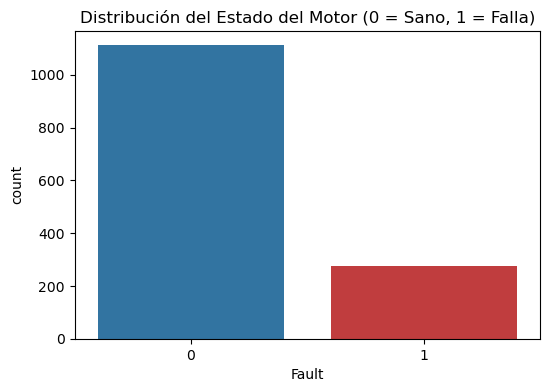

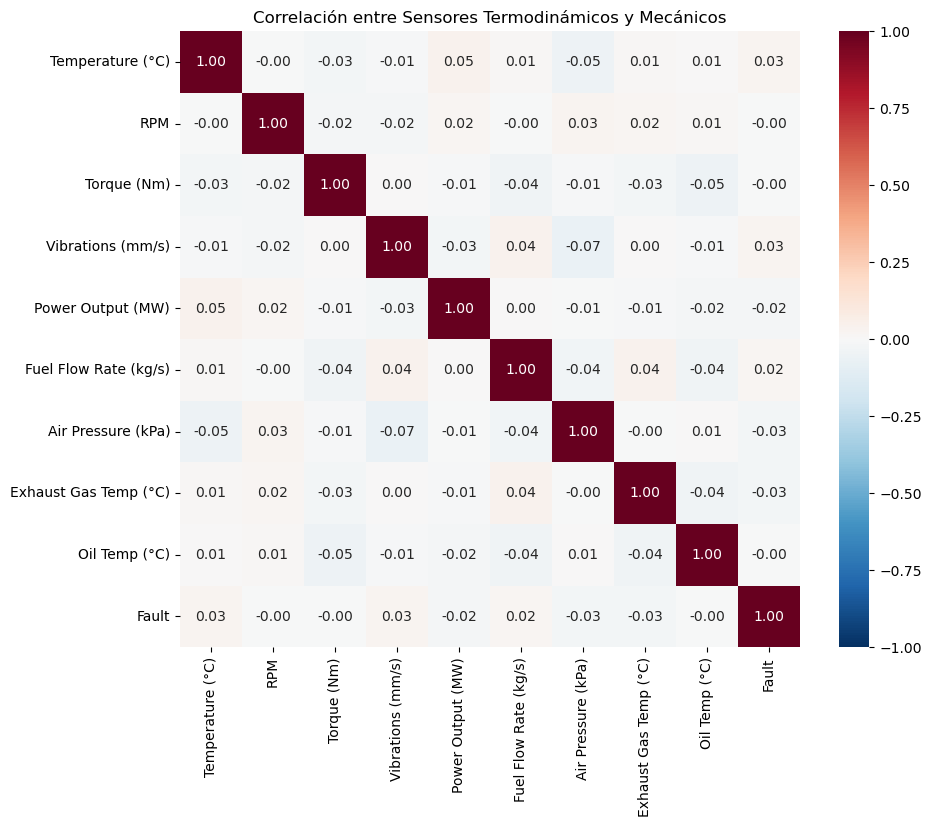

In [3]:
# Celda 2: EDA
import matplotlib.pyplot as plt
import seaborn as sns

print("Resumen estadístico de los sensores (Tabla):")
display(df.describe())

# Gráfica 1: Balance de clases
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Fault', palette=['#1f77b4', '#d62728'])
plt.title('Distribución del Estado del Motor (0 = Sano, 1 = Falla)')
plt.show()

# Gráfica 2: Matriz de Correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación entre Sensores Termodinámicos y Mecánicos')
plt.show()

Etapa 3: Limpieza de Datos (Data Cleaning)
Verificamos y tratamos valores nulos o duplicados que puedan arruinar el entrenamiento (el ruido o drift del que hablamos en la tesis).

In [4]:
# Celda 3: Limpieza
print("Cantidad de valores nulos por sensor (Tabla):")
nulos = df.isnull().sum()
display(pd.DataFrame(nulos, columns=['Valores Nulos']))

print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

# Si hubiera nulos, la estrategia común en series temporales/motores es rellenar con el valor anterior o la media:
# df = df.fillna(df.mean())
# df = df.drop_duplicates()

Cantidad de valores nulos por sensor (Tabla):


,Valores Nulos
Temperature (°C),0
RPM,0
Torque (Nm),0
Vibrations (mm/s),0
Power Output (MW),0
Fuel Flow Rate (kg/s),0
Air Pressure (kPa),0
Exhaust Gas Temp (°C),0
Oil Temp (°C),0
Fault,0


Filas duplicadas encontradas: 0


Etapa 4: División de Datos (Test y Training)
Separamos el histórico para entrenar al modelo y dejamos una parte "oculta" para probar su eficacia real.

Distribución tras la división (Gráfica de pastel):


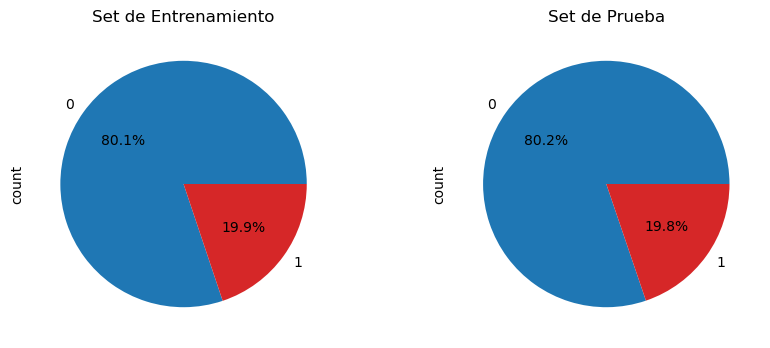

In [5]:
# Celda 4: División
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Fault'])
y = df['Fault']

# stratify=y garantiza que tanto el set de entrenamiento como el de prueba mantengan 
# la misma proporción de fallos (ej. 20%) que el dataset original.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Distribución tras la división (Gráfica de pastel):")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#1f77b4', '#d62728'], title='Set de Entrenamiento')
y_test.value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#1f77b4', '#d62728'], title='Set de Prueba')
plt.show()

Etapa 5: Normalización
Regla de oro: La normalización (escalado) siempre se hace después de dividir los datos (Etapa 4). Si escalas antes, los datos de prueba "contaminan" a los de entrenamiento (Data Leakage).

In [6]:
# Celda 5: Normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# fit_transform aprende la media/desviación SOLO del set de entrenamiento y lo escala
X_train_scaled = scaler.fit_transform(X_train)
# transform aplica esa misma regla al set de prueba
X_test_scaled = scaler.transform(X_test)

# Volvemos a convertirlos en DataFrames para no perder los nombres de las columnas (vital para SHAP)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Datos normalizados (Media cercana a 0, Desviación de 1):")
display(X_train_scaled.head())

Datos normalizados (Media cercana a 0, Desviación de 1):


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temp (°C),Oil Temp (°C)
0,-1.169638,-0.876584,1.657796,-1.154843,1.285557,0.017571,-0.875494,1.278367,-0.146295
1,0.874316,0.442895,-0.897369,-1.795115,0.947959,1.759449,1.070113,-0.116060,1.430532
2,-0.916030,-0.575207,1.185667,0.910813,-0.538244,0.164852,-1.517080,-0.970156,-0.006947
3,0.736184,-1.311852,0.402870,-0.798944,-1.078485,-0.380066,1.040835,-0.347408,0.904314
4,-0.749081,-0.058354,-1.118970,-0.536668,-0.292124,-1.519197,0.286569,1.324538,-1.155969


Etapa 6: Entrenamiento del Modelo
Entrenamos el clasificador de Bosques Aleatorios.

¡Modelo entrenado exitosamente!


C:\Users\10138083\AppData\Local\Temp\ipykernel_7584\3531641342.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


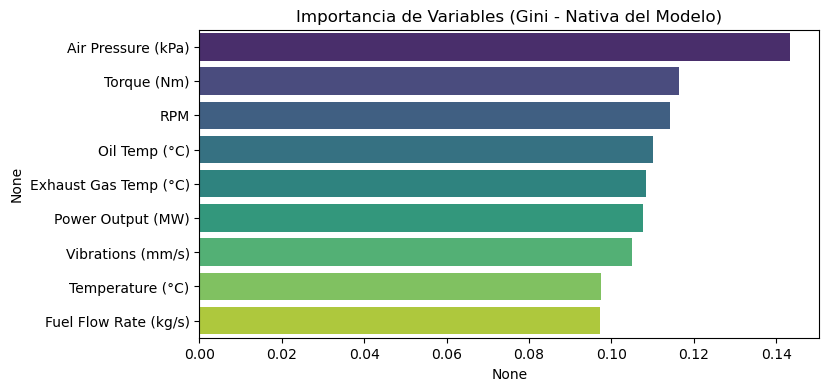

In [7]:
# Celda 6: Entrenamiento
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' es crucial para datasets industriales donde las fallas son eventos raros.
modelo_rf = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

print("¡Modelo entrenado exitosamente!")
# Al ser una etapa de cálculo, visualizamos la importancia intrínseca (Feature Importance base)
importances = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Importancia de Variables (Gini - Nativa del Modelo)')
plt.show()

Etapa 7: Métricas de Evaluación
Evaluamos cómo se comporta el modelo frente a los datos que nunca ha visto (el set de prueba).

Reporte de Clasificación Detallado (Tabla):


,precision,recall,f1-score,support
0,0.802,0.982,0.883,223.000
1,0.200,0.018,0.033,55.000
accuracy,0.791,0.791,0.791,0.791
macro avg,0.501,0.500,0.458,278.000
weighted avg,0.683,0.791,0.715,278.000


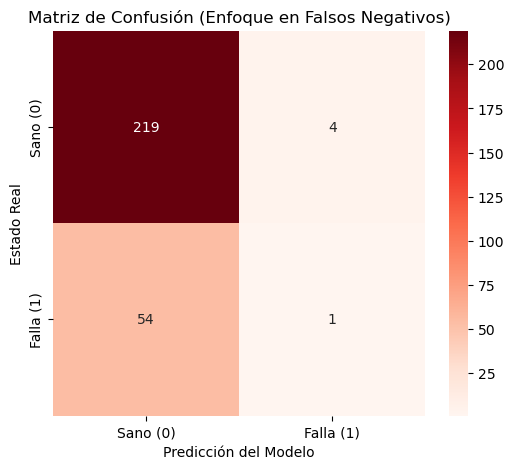

In [8]:
# Celda 7: Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = modelo_rf.predict(X_test_scaled)
y_pred_proba = modelo_rf.predict_proba(X_test_scaled)[:, 1]

print("Reporte de Clasificación Detallado (Tabla):")
# Usamos un DataFrame para que se vea más profesional en VS Code
reporte = classification_report(y_test, y_pred, output_dict=True)
display(pd.DataFrame(reporte).transpose().round(3))

# Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Sano (0)', 'Falla (1)'], yticklabels=['Sano (0)', 'Falla (1)'])
plt.title('Matriz de Confusión (Enfoque en Falsos Negativos)')
plt.ylabel('Estado Real')
plt.xlabel('Predicción del Modelo')
plt.show()

Etapa 8: Explicabilidad (XAI - SHAP)
Esta es la parte central para tu TFM: abrir la "caja negra".

In [10]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



Generando explicabilidad algorítmica (SHAP)...


C:\Users\10138083\AppData\Local\Temp\ipykernel_7584\589763629.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_falla, X_test_scaled, show=False)


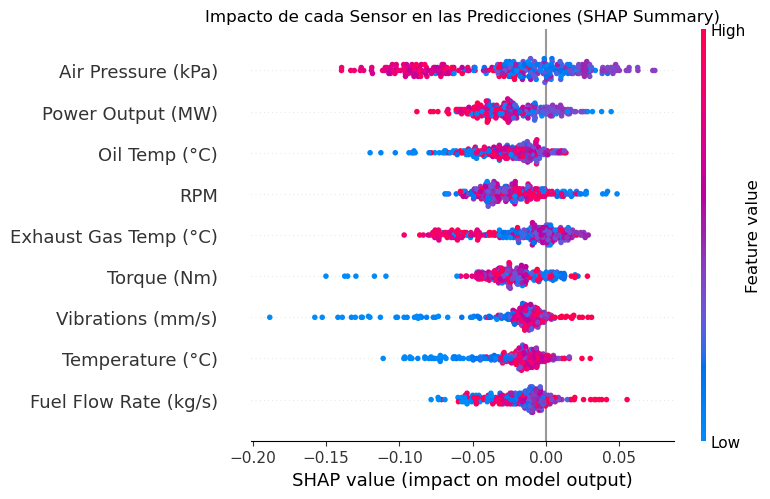


Auditoría XAI del evento de falla #1:


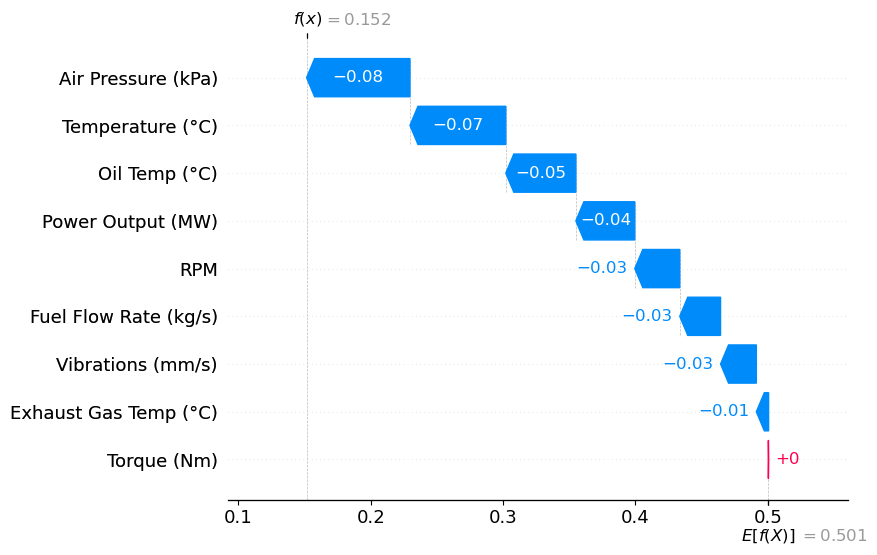

In [12]:
# Celda 8: Explicabilidad (SHAP)
import shap
import numpy as np
import matplotlib.pyplot as plt

print("Generando explicabilidad algorítmica (SHAP)...")
explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer.shap_values(X_test_scaled)

# --- CORRECCIÓN DE COMPATIBILIDAD SHAP ---
# Detectamos inteligentemente el formato de salida según la versión de SHAP instalada
if isinstance(shap_values, list):
    # Formato antiguo: lista de matrices [clase_0, clase_1]
    valores_shap_falla = shap_values[1]
    valor_base = explainer.expected_value[1]
elif len(np.array(shap_values).shape) == 3:
    # Formato intermedio: matriz 3D (muestras, características, clases)
    valores_shap_falla = shap_values[:, :, 1]
    valor_base = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    # Formato nuevo: matriz 2D directa para la clase analizada
    valores_shap_falla = shap_values
    valor_base = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

# 1. Gráfico Resumen Global
plt.figure()
plt.title('Impacto de cada Sensor en las Predicciones (SHAP Summary)')
shap.summary_plot(valores_shap_falla, X_test_scaled, show=False) 
plt.tight_layout()
plt.show()

# 2. Explicabilidad Local (Caso Crítico de Falla)
# Encontramos la primera fila del test donde el motor falló realmente
indice_critico = y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == 1].index[0]

print(f"\nAuditoría XAI del evento de falla #{indice_critico}:")

# Gráfico de cascada utilizando las variables compatibilizadas
shap.plots._waterfall.waterfall_legacy(
    valor_base, 
    valores_shap_falla[indice_critico], 
    feature_names=X_test_scaled.columns, 
    show=True
)